# Phase 3 Pipeline

Apply regularization and compare models on the same split.

In [1]:
from __future__ import annotations

import json
import pickle
from pathlib import Path
from typing import Any

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import LabelEncoder

from phase3_train_pipeline import (
    Phase3Config,
    compute_drift_report,
    fit_models,
    load_and_split,
    prune_features,
    save_calibration_plot,
    save_plots,
)

/home/vectone/MyProjects/IPL-Winner-Prediction/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [2]:
INPUT_PATH = Path("../../data/raw/IPL_Winner_Model_Dataset_With_Players.csv")
RESULTS_DIR = Path("results")
ARTIFACTS_DIR = Path("artifacts")
cfg = Phase3Config(test_year=2025, min_category_freq=8, max_categories_per_player_col=80)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("Input:", INPUT_PATH)
print("Results dir:", RESULTS_DIR)
print("Artifacts dir:", ARTIFACTS_DIR)
print("Config:", cfg)

Input: ../../data/raw/IPL_Winner_Model_Dataset_With_Players.csv
Results dir: results
Artifacts dir: artifacts
Config: Phase3Config(test_year=2025, min_category_freq=8, max_categories_per_player_col=80)


## Train and compare

In [3]:
train_df_raw, test_df_raw = load_and_split(INPUT_PATH, test_year=cfg.test_year)
train_df = prune_features(train_df_raw)
test_df = prune_features(test_df_raw)

drop_cols = ["Match_Winner", "Match_ID", "Date"]
feature_columns = [c for c in train_df.columns if c not in drop_cols]
player_slot_cols = [c for c in feature_columns if c.startswith("Team1_Player_") or c.startswith("Team2_Player_")]

X_train = train_df[feature_columns].copy()
X_test = test_df[feature_columns].copy()

y_train_raw = train_df["Match_Winner"].astype(str).values
y_test_raw = test_df["Match_Winner"].astype(str).values

label_encoder = LabelEncoder()
label_encoder.fit(np.concatenate([y_train_raw, y_test_raw]))
y_train = label_encoder.transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)

best_models, metrics = fit_models(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    player_slot_cols=player_slot_cols,
    cfg=cfg,
)

metrics_df = pd.DataFrame.from_dict(metrics, orient="index").reset_index(names=["model"])
metrics_df = metrics_df.sort_values("test_f1_weighted", ascending=False).reset_index(drop=True)

best_model_name = str(metrics_df.loc[0, "model"])
best_bundle = best_models[best_model_name]
best_model = best_bundle["pipeline"]

y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)

print("Best model:", best_model_name)
metrics_df

Phase 3 model training: 100%|██████████| 3/3 [01:13<00:00, 24.62s/model, logistic_reg_l2]  

Best model: logistic_reg_l2


,model,train_accuracy,test_accuracy,train_balanced_accuracy,test_balanced_accuracy,train_f1_weighted,test_f1_weighted,test_f1_macro,test_precision_weighted,test_recall_weighted,test_log_loss,top2_accuracy,top3_accuracy,calibration_ece,multiclass_brier,fit_gap_weighted_f1,best_cv_weighted_f1
0,logistic_reg_l2,0.869048,0.513514,0.905587,0.500413,0.868482,0.490241,0.451556,0.532635,0.513514,1.547856,0.878378,0.918919,0.238953,0.704977,0.378241,0.485668
1,xgboost_reg,0.512987,0.540541,0.360815,0.518779,0.482807,0.463686,0.433016,0.421666,0.540541,1.582426,0.783784,0.797297,0.217958,0.671235,0.019121,0.457226
2,random_forest_reg,0.629870,0.472973,0.693221,0.439302,0.617593,0.450591,0.408558,0.514736,0.472973,1.739578,0.824324,0.918919,0.247931,0.751217,0.167002,0.507725


## Save outputs and reports

In [4]:
labels = list(range(len(label_encoder.classes_)))
report = classification_report(
    y_test,
    y_pred_best,
    labels=labels,
    target_names=label_encoder.classes_.tolist(),
    zero_division=0,
    output_dict=True,
)

save_plots(metrics_df, RESULTS_DIR)

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    labels=labels,
    display_labels=label_encoder.classes_,
    xticks_rotation=90,
    cmap="Blues",
    ax=ax,
    colorbar=False,
)
ax.set_title(f"Phase 3 Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "phase3_best_model_confusion_matrix.png", dpi=160)
plt.close()

save_calibration_plot(y_test, y_proba_best, RESULTS_DIR / "phase3_best_model_reliability_plot.png")

drift_report = compute_drift_report(train_df, test_df, player_slot_cols)
model_monitoring = {
    "train_years": sorted(train_df_raw["Date"].dt.year.unique().tolist()),
    "test_years": sorted(test_df_raw["Date"].dt.year.unique().tolist()),
    "drift_report": drift_report,
}

metrics_df.to_csv(RESULTS_DIR / "phase3_model_comparison_metrics.csv", index=False)
with (RESULTS_DIR / "phase3_best_model_classification_report.json").open("w", encoding="utf-8") as f:
    json.dump(report, f, indent=2)
with (RESULTS_DIR / "phase3_model_monitoring_report.json").open("w", encoding="utf-8") as f:
    json.dump(model_monitoring, f, indent=2)

metadata = {
    "phase": 3,
    "train_file": str(INPUT_PATH),
    "train_size": int(len(train_df)),
    "test_size": int(len(test_df)),
    "test_year": cfg.test_year,
    "feature_count": int(len(feature_columns)),
    "features_after_pruning": feature_columns,
    "player_slot_columns": player_slot_cols,
    "cardinality_controls": {
        "min_category_freq": cfg.min_category_freq,
        "max_categories_per_player_col": cfg.max_categories_per_player_col,
        "onehot_min_frequency": 6,
    },
    "models_evaluated": metrics_df["model"].tolist(),
    "model_metrics": metrics,
    "best_model": best_model_name,
    "best_model_params": best_bundle["best_params"],
    "best_model_test_metrics": metrics[best_model_name],
}

bundle = {
    "model_pipeline": best_model,
    "label_encoder": label_encoder,
    "feature_columns": feature_columns,
    "metadata": metadata,
}

joblib.dump(bundle, ARTIFACTS_DIR / "phase3_ipl_winner_best_pipeline.joblib")
with (ARTIFACTS_DIR / "phase3_ipl_winner_best_pipeline.pkl").open("wb") as f:
    pickle.dump(bundle, f)
with (ARTIFACTS_DIR / "phase3_model_metadata.json").open("w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

sample_payload = X_test.iloc[0].to_dict()
with (RESULTS_DIR / "phase3_sample_prediction_payload.json").open("w", encoding="utf-8") as f:
    json.dump(sample_payload, f, indent=2)

print(f"Saved results to: {RESULTS_DIR}")
print(f"Saved artifacts to: {ARTIFACTS_DIR}")
print("Best model test metrics:", metadata["best_model_test_metrics"])

Saved results to: results
Saved artifacts to: artifacts
Best model test metrics: {'train_accuracy': 0.8690476190476191, 'test_accuracy': 0.5135135135135135, 'train_balanced_accuracy': 0.9055871221410068, 'test_balanced_accuracy': 0.5004132231404959, 'train_f1_weighted': 0.8684821186189289, 'test_f1_weighted': 0.4902407757098833, 'test_f1_macro': 0.45155627374266855, 'test_precision_weighted': 0.5326345576345577, 'test_recall_weighted': 0.5135135135135135, 'test_log_loss': 1.5478560834565074, 'top2_accuracy': 0.8783783783783784, 'top3_accuracy': 0.918918918918919, 'calibration_ece': 0.23895334722855024, 'multiclass_brier': 0.7049766948746367, 'fit_gap_weighted_f1': 0.3782413429090456, 'best_cv_weighted_f1': 0.4856676452007716}


## Review charts

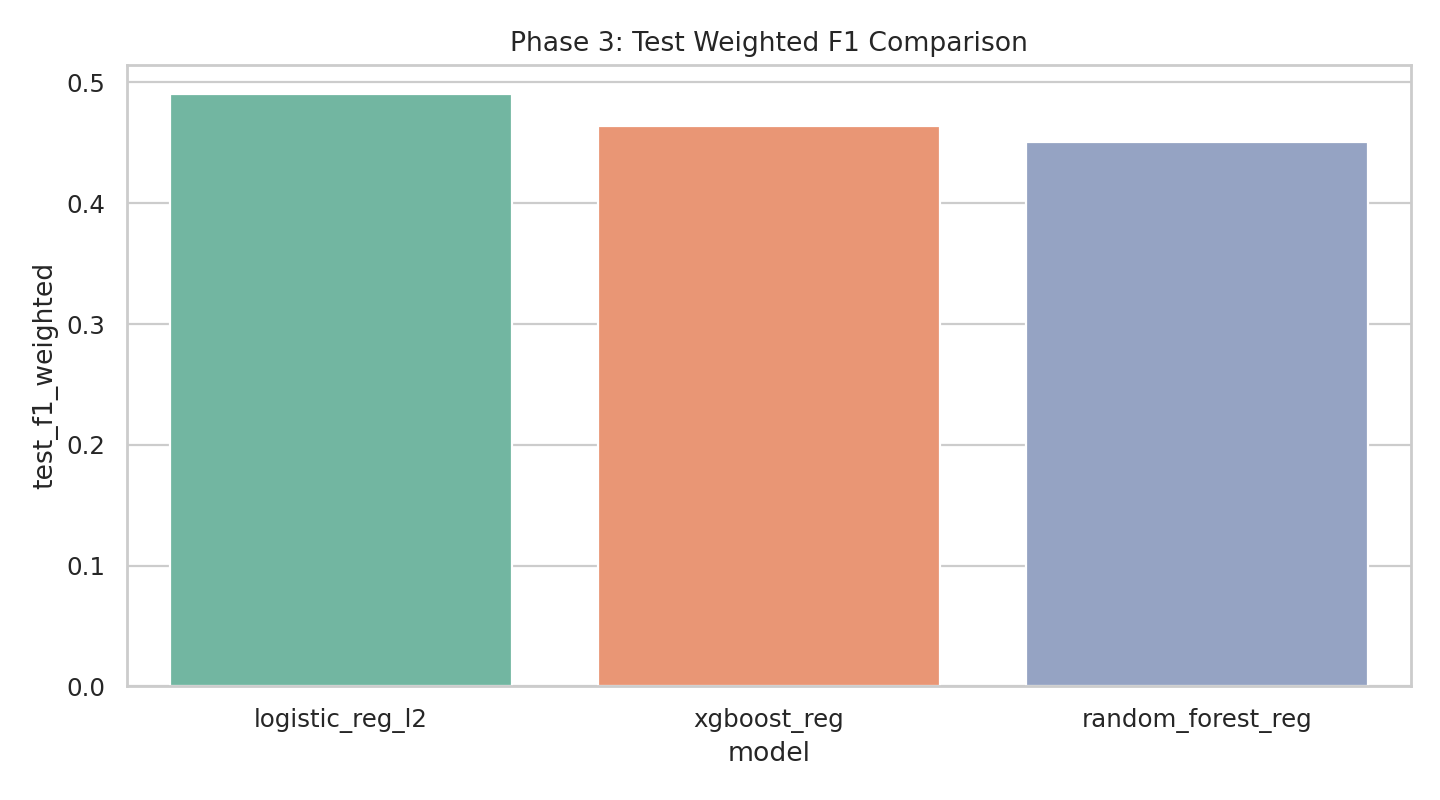

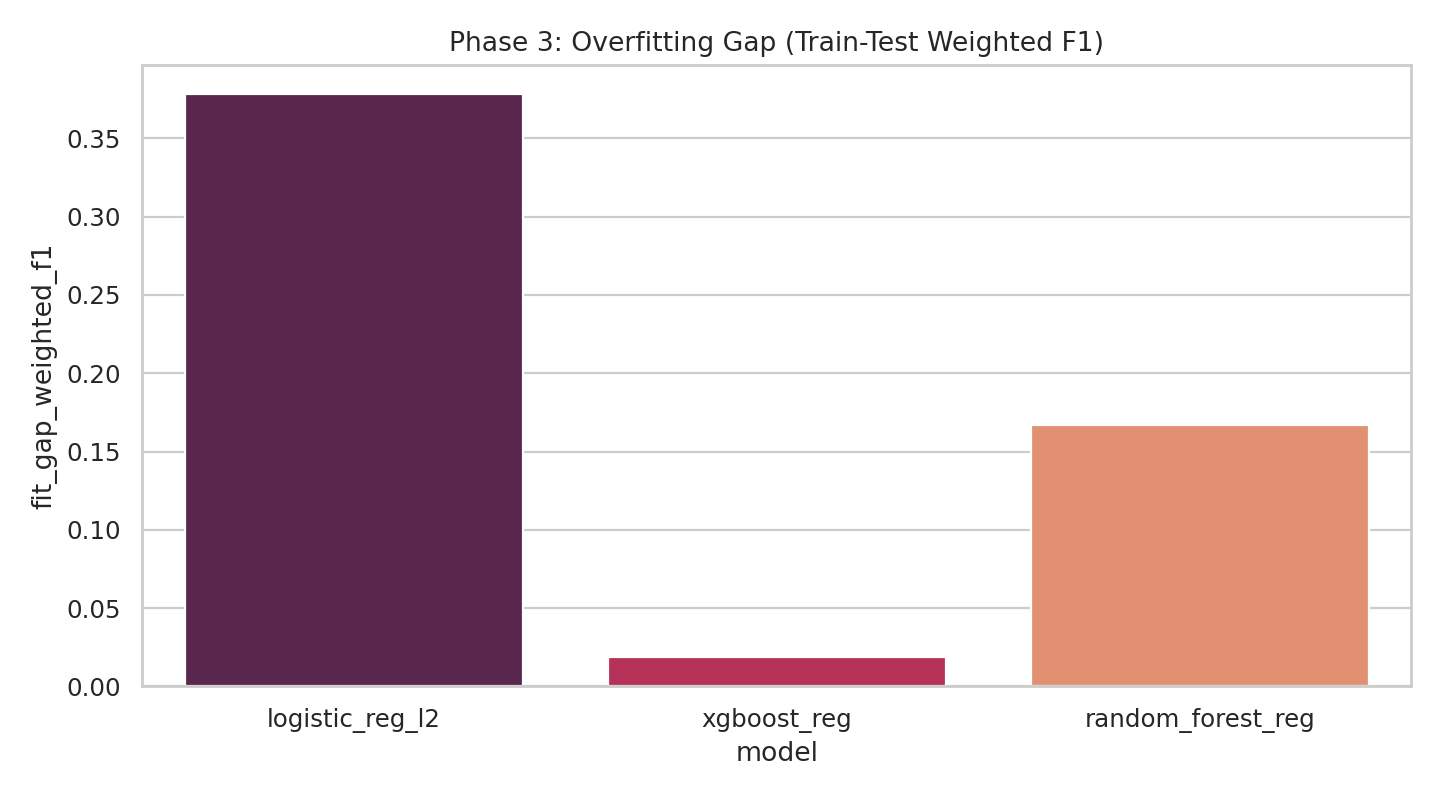

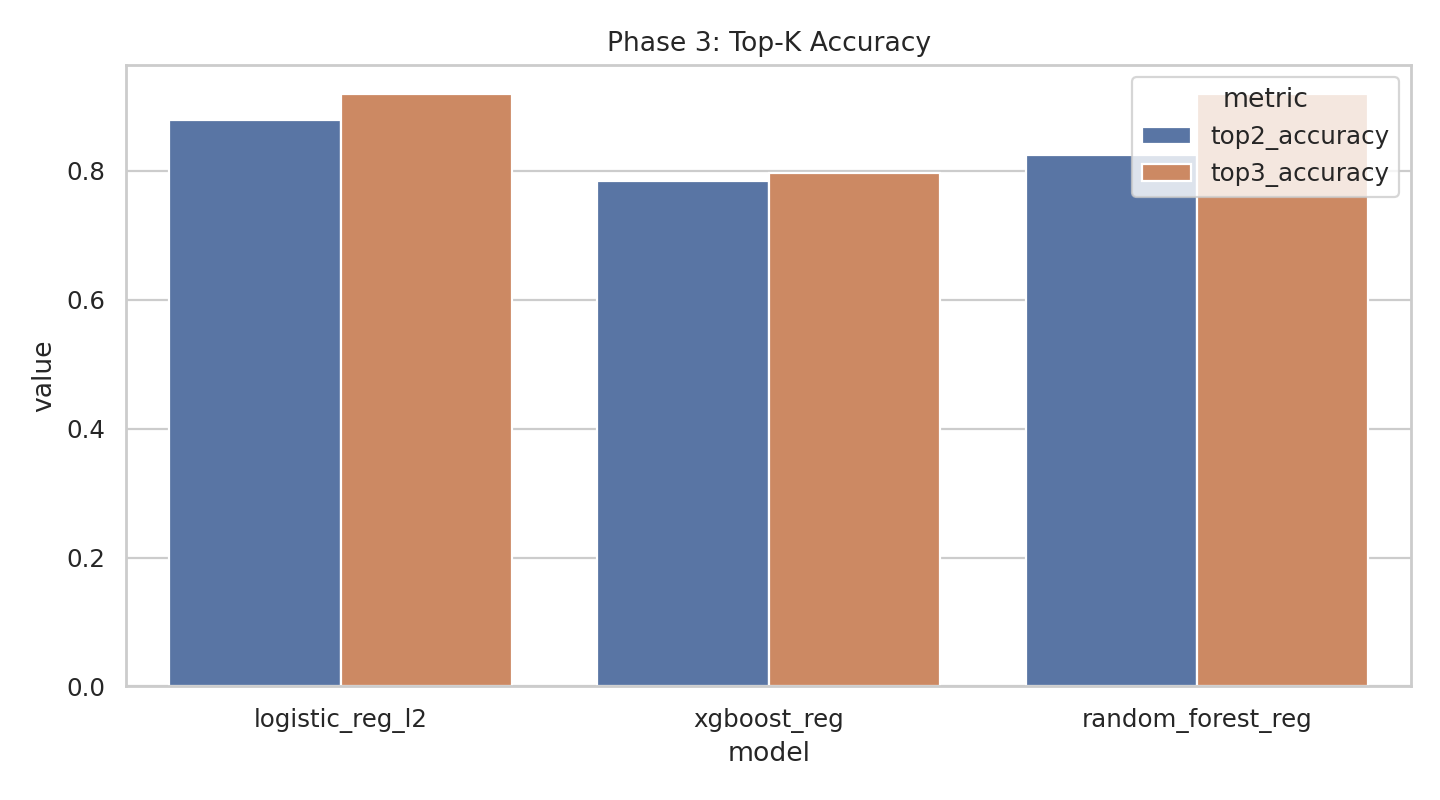

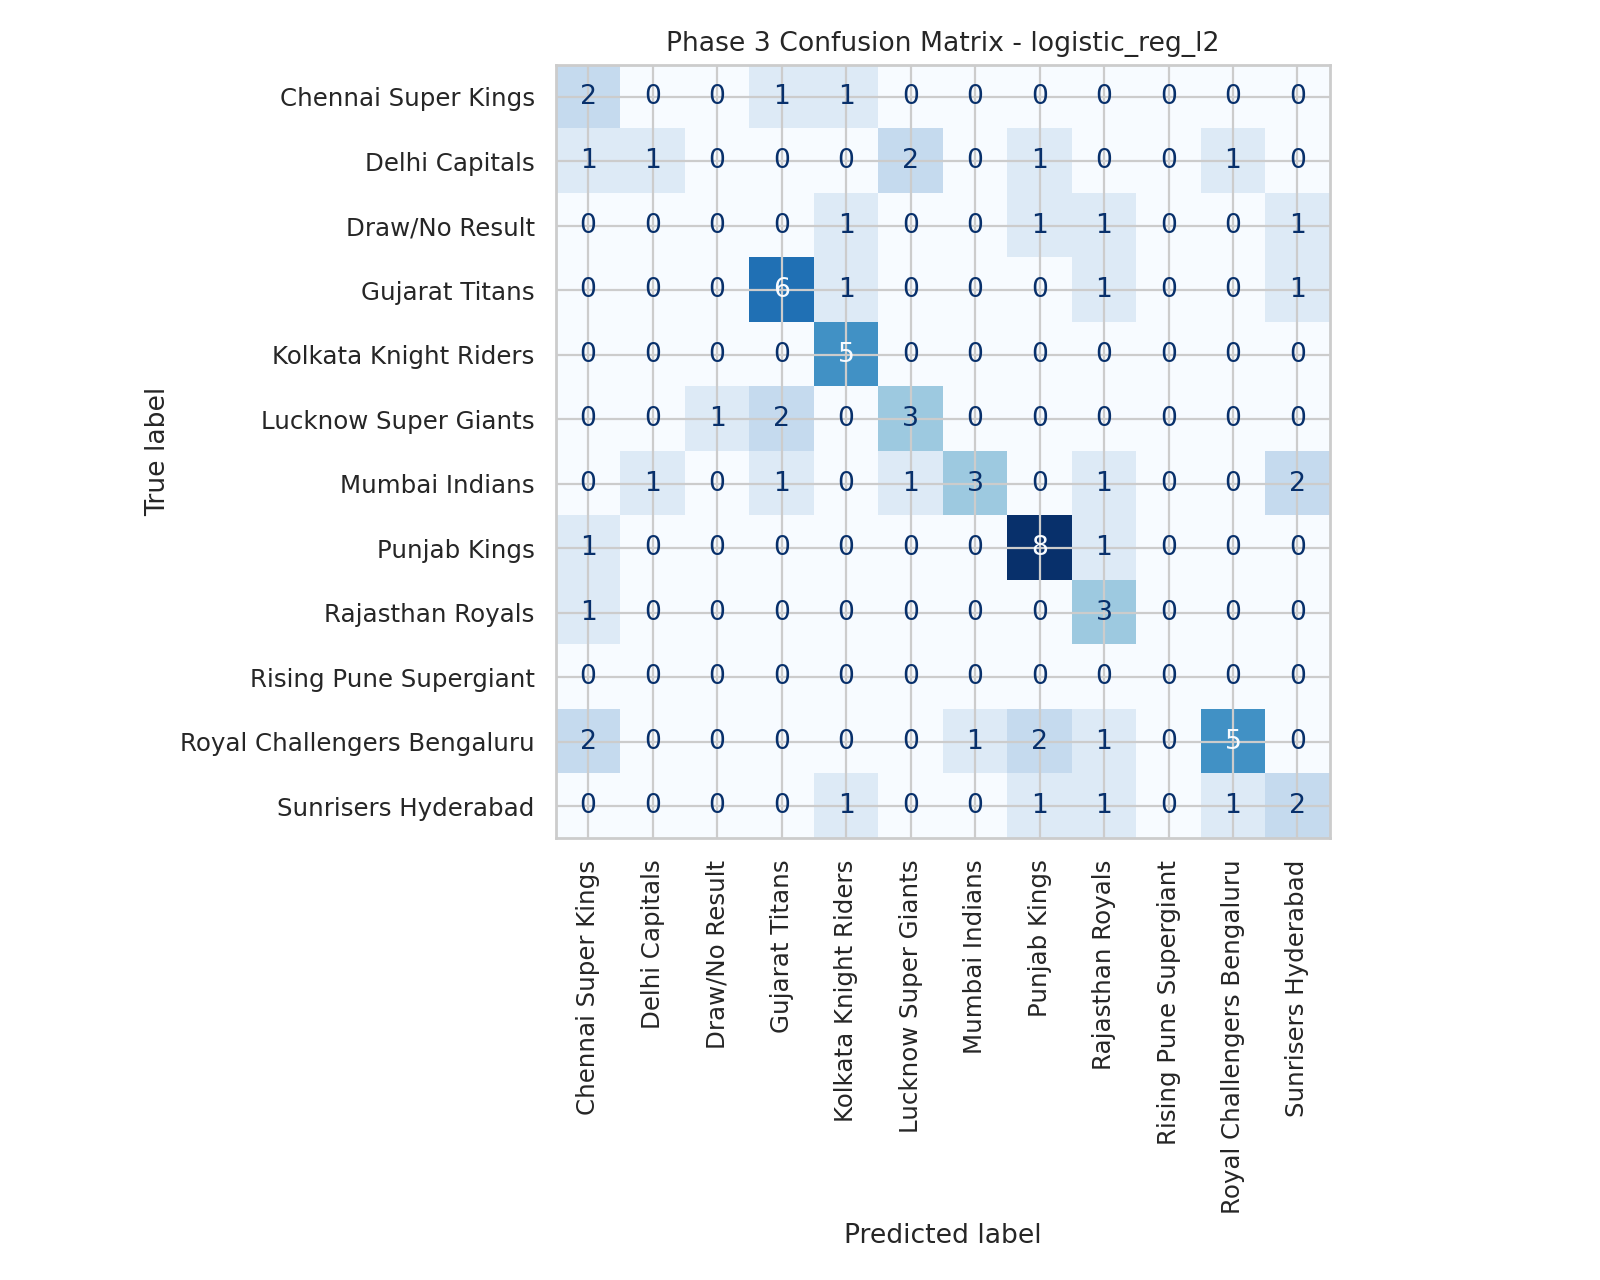

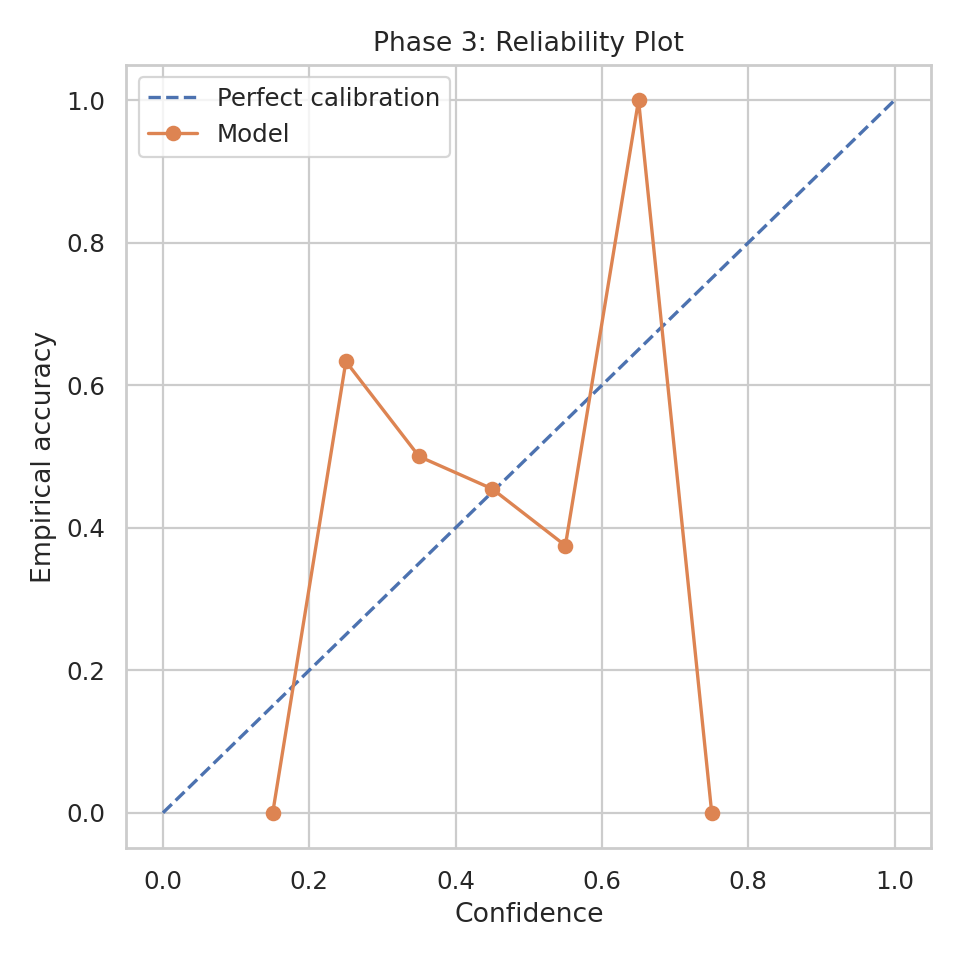

Best model: logistic_reg_l2
Best model params: {'model__C': 0.1}


{'train_accuracy': 0.8690476190476191,
 'test_accuracy': 0.5135135135135135,
 'train_balanced_accuracy': 0.9055871221410068,
 'test_balanced_accuracy': 0.5004132231404959,
 'train_f1_weighted': 0.8684821186189289,
 'test_f1_weighted': 0.4902407757098833,
 'test_f1_macro': 0.45155627374266855,
 'test_precision_weighted': 0.5326345576345577,
 'test_recall_weighted': 0.5135135135135135,
 'test_log_loss': 1.5478560834565074,
 'top2_accuracy': 0.8783783783783784,
 'top3_accuracy': 0.918918918918919,
 'calibration_ece': 0.23895334722855024,
 'multiclass_brier': 0.7049766948746367,
 'fit_gap_weighted_f1': 0.3782413429090456,
 'best_cv_weighted_f1': 0.4856676452007716}

In [5]:
display(Image(filename=str(RESULTS_DIR / "phase3_model_comparison_test_f1.png")))
display(Image(filename=str(RESULTS_DIR / "phase3_overfit_gap.png")))
display(Image(filename=str(RESULTS_DIR / "phase3_topk_accuracy.png")))
display(Image(filename=str(RESULTS_DIR / "phase3_best_model_confusion_matrix.png")))
display(Image(filename=str(RESULTS_DIR / "phase3_best_model_reliability_plot.png")))

meta = json.loads((ARTIFACTS_DIR / "phase3_model_metadata.json").read_text(encoding="utf-8"))
print("Best model:", meta["best_model"])
print("Best model params:", meta["best_model_params"])
meta["best_model_test_metrics"]